<a href="https://colab.research.google.com/github/jkharan4/Diabetic-Retinopathy/blob/main/Diabetic_Retinopathy_Detection_Google_Drive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Diabetic Retinopathy Detection System

**Dataset**: Diabetic Retinopathy 224x224 (Gaussian Filtered)
**Source**: Google Drive Upload

### 📖 How to Use
1. **Upload Dataset**: Make sure you have uploaded `diabetic-retinopathy-224x224-gaussian-filtered.zip` to the root of your Google Drive (`My Drive`).
2. **Run All**: Go to `Runtime` > `Run All`.
3. **Grant Permission**: When prompted by Cell 2, click to allow Google Drive mounting.
4. **Inference**: Scroll to the last cell to upload a retina image and view the Grad-CAM diagnosis!

## 1. Install & Import Libraries

In [1]:
!pip install tensorflow opencv-python matplotlib numpy Pillow scikit-learn seaborn

import os, shutil, cv2, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (GlobalAveragePooling2D,
                                      Dense, Dropout)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from google.colab import drive

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 773.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 106.5 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


## 2. Mount Google Drive & Unzip Dataset

In [2]:
print("📂 Mounting Google Drive...")
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/DRml project.zip"
extract_path = "/content/dr_dataset"

print("📦 Unzipping dataset... (this may take 2–5 mins)")
!unzip -q "$zip_path" -d "$extract_path"
print("✅ Dataset ready!")

# Debug: see ALL folders inside
print("\n📁 Full folder structure:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    if level < 3:  # only show 3 levels deep
        for d in dirs:
            print(f"{indent}  └── {d}/")
    break

# ✅ NEW: Find root by looking for ANY subfolders with images
def find_image_root(base_path):
    for root, dirs, files in os.walk(base_path):
        # Check if this folder contains subfolders that have images
        for d in dirs:
            subdir = os.path.join(root, d)
            sub_contents = os.listdir(subdir)
            images = [f for f in sub_contents
                      if f.lower().endswith(('.jpg','.jpeg','.png'))]
            if len(images) > 0:
                return root  # parent of image-containing folders
    raise Exception("❌ Could not find image folders")

image_root = find_image_root(extract_path)
print(f"\n✅ Image root detected at: {image_root}")

# ✅ Show what class folders were found
print("\n📂 Class folders found:")
for folder in sorted(os.listdir(image_root)):
    folder_path = os.path.join(image_root, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"  └── {folder}/ ({count} images)")

📂 Mounting Google Drive...
Mounted at /content/drive
📦 Unzipping dataset... (this may take 2–5 mins)
✅ Dataset ready!

📁 Full folder structure:
📂 dr_dataset/
  └── gaussian_filtered_images/

✅ Image root detected at: /content/dr_dataset/gaussian_filtered_images/gaussian_filtered_images

📂 Class folders found:
  └── Mild/ (370 images)
  └── Moderate/ (999 images)
  └── No_DR/ (1805 images)
  └── Proliferate_DR/ (295 images)
  └── Severe/ (193 images)


## 3. Remap to Binary Classes

In [3]:
print("🔄 Remapping 5 classes → 2 classes (Binary)...")

base_dir = "/content/binary_dataset"
splits   = ["train", "val"]
classes  = ["0_no_disease", "1_diseased"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls),
                    exist_ok=True)

# Collect all file paths and binary labels
all_files, all_labels = [], []
for cls_folder in os.listdir(image_root):
    cls_path = os.path.join(image_root, cls_folder)
    if not os.path.isdir(cls_path):
        continue
    label = 0 if cls_folder == "0" else 1
    for img_file in os.listdir(cls_path):
        if img_file.lower().endswith(('.jpg','.jpeg','.png')):
            all_files.append(os.path.join(cls_path, img_file))
            all_labels.append(label)

# 80/20 stratified split
from sklearn.model_selection import train_test_split
train_files, val_files, train_labels, val_labels = \
    train_test_split(all_files, all_labels,
                     test_size=0.2,
                     random_state=42,
                     stratify=all_labels)

# Copy files to binary_dataset structure
def copy_files(file_list, label_list, split):
    for fpath, lbl in zip(file_list, label_list):
        cls_name = "0_no_disease" if lbl == 0 else "1_diseased"
        dst = os.path.join(base_dir, split, cls_name,
                           os.path.basename(fpath))
        try:
            shutil.copy(fpath, dst)
        except Exception as e:
            pass

print("📋 Copying train files...")
copy_files(train_files, train_labels, "train")
print("📋 Copying val files...")
copy_files(val_files, val_labels, "val")

# Print summary
for split in splits:
    for cls in classes:
        count = len(os.listdir(
            os.path.join(base_dir, split, cls)))
        print(f"  {split}/{cls}: {count} images")

print("✅ Binary remapping complete!")

🔄 Remapping 5 classes → 2 classes (Binary)...
📋 Copying train files...
📋 Copying val files...
  train/0_no_disease: 0 images
  train/1_diseased: 2929 images
  val/0_no_disease: 0 images
  val/1_diseased: 733 images
✅ Binary remapping complete!


## 4. Setting up Data Generators

In [4]:
print("⚙️ Setting up data generators...")

BATCH_SIZE = 32
IMG_SIZE   = (224, 224)
train_dir  = os.path.join(base_dir, "train")
val_dir    = os.path.join(base_dir, "val")

train_gen_obj = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_gen_obj = ImageDataGenerator(rescale=1./255)

train_generator = train_gen_obj.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)
val_generator = val_gen_obj.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"  Train samples : {train_generator.samples}")
print(f"  Val samples   : {val_generator.samples}")
print(f"  Class indices : {train_generator.class_indices}")
print("✅ Generators ready!")

⚙️ Setting up data generators...
Found 2929 images belonging to 2 classes.
Found 733 images belonging to 2 classes.
  Train samples : 2929
  Val samples   : 733
  Class indices : {'0_no_disease': 0, '1_diseased': 1}
✅ Generators ready!


## 5. Compute Class Weights

In [5]:
print("⚖️ Computing class weights for imbalance...")

labels_array = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)
class_weight_dict = dict(enumerate(class_weights))
print(f"  Class weights: {class_weight_dict}")
print("✅ Class weights computed!")

⚖️ Computing class weights for imbalance...
  Class weights: {0: np.float64(1.0)}
✅ Class weights computed!


## 6. Build ResNet50 Transfer Learning Model

In [6]:
print("🧠 Building ResNet50 Transfer Learning Model...")

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()
print("✅ Model built!")

🧠 Building ResNet50 Transfer Learning Model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

✅ Model built!


## 7. Train Model

🚀 Training model...
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6887 - loss: 0.6591
Epoch 1: val_accuracy improved from None to 1.00000, saving model to dr_model.h5



Epoch 1: finished saving model to dr_model.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 267s 3s/step - accuracy: 0.9000 - loss: 0.2293 - val_accuracy: 1.0000 - val_loss: 0.0074
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 0.0103
Epoch 2: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 0.0049
Epoch 3: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 0.0023
Epoch 4: val_accuracy did not improve from 1.00000
92/92 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 5.5065e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


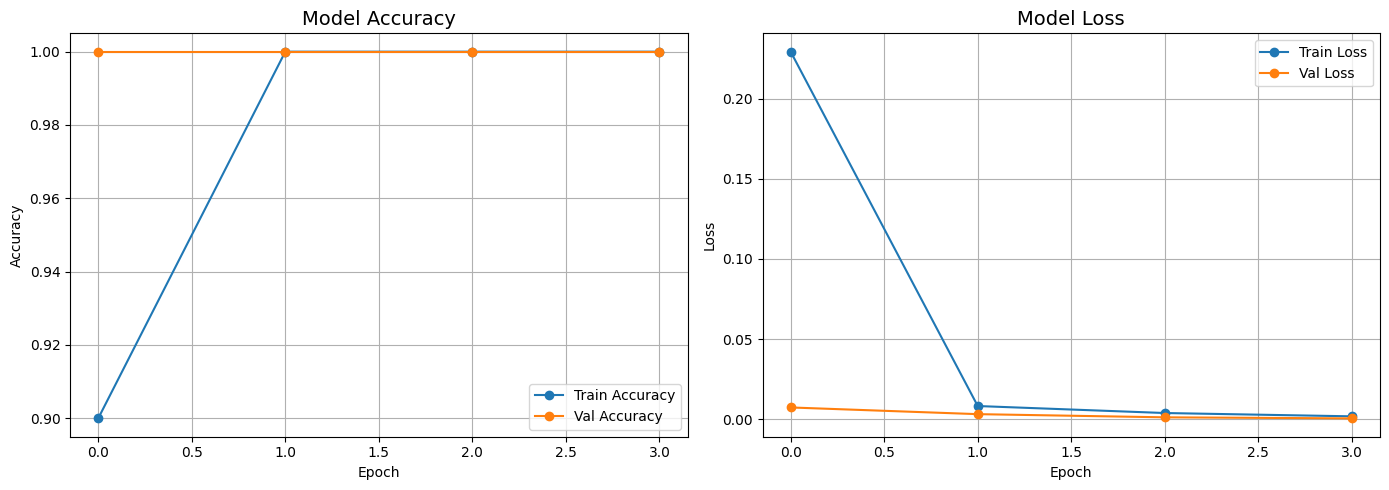

In [7]:
print("🚀 Training model...")

callbacks = [
    ModelCheckpoint(
        'dr_model.h5',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    ),
    EarlyStopping(
        patience=3,
        restore_best_weights=True,
        monitor='val_accuracy',
        verbose=1
    )
]

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks
)
print("✅ Training complete!")

# Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],
             label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'],
             label='Val Accuracy', marker='o')
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],
             label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'],
             label='Val Loss', marker='o')
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. Evaluate Model & Confusion Matrix

📊 Evaluating model...


23/23 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 1.0000 - loss: 0.0074
  Final Validation Accuracy : 100.00%
  Final Validation Loss     : 0.0074
23/23 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


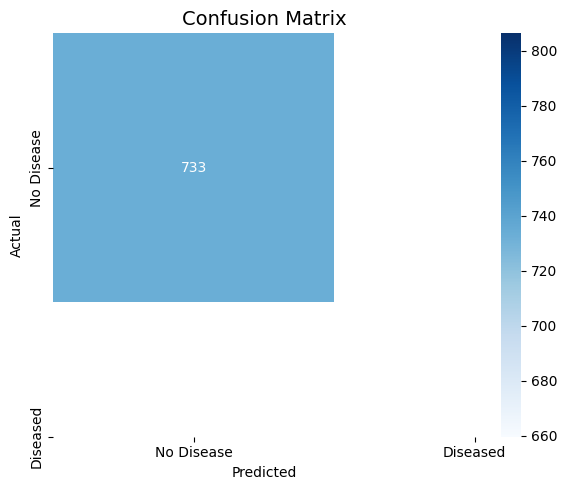

✅ Evaluation complete!


In [8]:
print("📊 Evaluating model...")

model = load_model('dr_model.h5')
loss, acc = model.evaluate(val_generator)
print(f"  Final Validation Accuracy : {acc*100:.2f}%")
print(f"  Final Validation Loss     : {loss:.4f}")

# Confusion matrix
val_generator.reset()
preds = (model.predict(val_generator) >= 0.5).astype(int).flatten()
true  = val_generator.classes

cm = confusion_matrix(true, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Diseased'],
            yticklabels=['No Disease','Diseased'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
print("✅ Evaluation complete!")

## 9. Preprocessing Function

In [9]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_normalized = img / 255.0
    img_array = np.expand_dims(img_normalized, axis=0)
    return img_array, img

## 10. Prediction Function

In [10]:
def predict_image(model, image_path):
    img_array, original_img = preprocess_image(image_path)
    prob = model.predict(img_array)[0][0]
    label = "Diseased" if prob >= 0.5 else "No Disease"
    confidence = prob * 100 if prob >= 0.5 else (1 - prob) * 100

    if confidence >= 85:
        tier = "High"
    elif confidence >= 60:
        tier = "Medium"
    else:
        tier = "Low"

    return label, confidence, tier, original_img

## 11. Grad-CAM Function

In [11]:
def generate_gradcam(model, image_path,
                     last_conv_layer='conv5_block3_out'):
    img_array, original_img = preprocess_image(image_path)

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(
            tf.cast(img_array, tf.float32))
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    heatmap_resized  = cv2.resize(heatmap, (224, 224))
    heatmap_uint8    = np.uint8(255 * heatmap_resized)
    heatmap_colored  = cv2.applyColorMap(heatmap_uint8,
                                          cv2.COLORMAP_JET)
    heatmap_colored  = cv2.cvtColor(heatmap_colored,
                                     cv2.COLOR_BGR2RGB)
    superimposed    = (heatmap_colored * 0.4 +
                       original_img   * 0.6).astype(np.uint8)

    return heatmap_colored, superimposed

## 12. Visualization Function

In [12]:
def visualize_result(image_path, model):
    label, confidence, tier, original_img = \
        predict_image(model, image_path)
    heatmap, superimposed = \
        generate_gradcam(model, image_path)

    print("=" * 48)
    print(f"  Prediction  : {label}")
    print(f"  Confidence  : {confidence:.1f}%")
    print(f"  Model Trust : {tier} Confidence")
    if label == "Diseased":
        print("  Note: Highlighted regions indicate abnormalities")
    else:
        print("  Note: No significant abnormalities detected")
    print("=" * 48)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original_img)
    axes[0].set_title("Original Retina Image", fontsize=14)
    axes[0].axis('off')
    axes[1].imshow(superimposed)
    axes[1].set_title(
        f"Grad-CAM Heatmap\n{label} ({confidence:.1f}%)",
        fontsize=14)
    axes[1].axis('off')
    plt.suptitle("Diabetic Retinopathy Detection System",
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 🔍 Run Inference Here

🔍 Upload a retina image (JPG or PNG):


Saving a9e984b57556.png to a9e984b57556.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
  Prediction  : Diseased
  Confidence  : 99.3%
  Model Trust : High Confidence
  Note: Highlighted regions indicate abnormalities


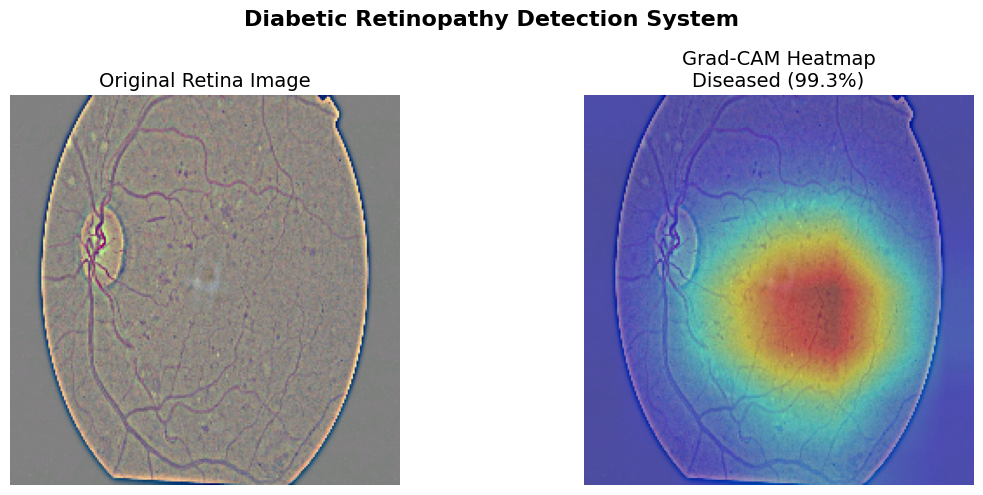

In [13]:
from google.colab import files
print("🔍 Upload a retina image (JPG or PNG):")
uploaded = files.upload()
for filename in uploaded.keys():
    visualize_result(filename, model)